# Augmentation Frequency by Main UniProt

This notebook counts how many times each main UniProt entry was augmented in `datasets/final_dataset_with_seq.csv`.

Here, `augmentated from uniprot ID` is treated as the main UniProt ID, and rows with `uniprot_id != augmentated from uniprot ID` are defined as truly augmented samples.

In [1]:
import csv
from collections import Counter
from pathlib import Path

dataset_path = Path("datasets/final_dataset_with_seq.csv")

with dataset_path.open("r", encoding="utf-8", newline="") as f:
    rows = list(csv.DictReader(f))

print(f"dataset path: {dataset_path}")
print(f"total rows: {len(rows)}")
print("columns:")
for column in rows[0].keys():
    print(f"- {column}")

dataset path: datasets/final_dataset_with_seq.csv
total rows: 2790
columns:
- uniprot_id
- sequence
- site
- label
- augmentated from uniprot ID
- human Site and Mutation
- usage


## 1. Count the Number of Augmentations for Each Main UniProt

Field definitions:

- `main_uniprot_id`: the main UniProt ID, i.e. `augmentated from uniprot ID`
- `total_rows_from_main`: total number of rows associated with this main UniProt
- `original_rows`: number of original rows where `uniprot_id == main_uniprot_id`
- `augmented_rows`: number of truly augmented rows
- `unique_augmented_uniprot_ids`: number of distinct augmented UniProt IDs generated from this main UniProt

In [2]:
source_col = "augmentated from uniprot ID"
current_col = "uniprot_id"

stats_by_main = {}

for row in rows:
    main_uniprot = row[source_col].strip()
    current_uniprot = row[current_col].strip()

    if main_uniprot not in stats_by_main:
        stats_by_main[main_uniprot] = {
            "total_rows_from_main": 0,
            "original_rows": 0,
            "augmented_rows": 0,
            "unique_augmented_uniprot_ids": set(),
        }

    stats = stats_by_main[main_uniprot]
    stats["total_rows_from_main"] += 1

    if current_uniprot == main_uniprot:
        stats["original_rows"] += 1
    else:
        stats["augmented_rows"] += 1
        stats["unique_augmented_uniprot_ids"].add(current_uniprot)

summary_rows = []
for main_uniprot, stats in stats_by_main.items():
    summary_rows.append({
        "main_uniprot_id": main_uniprot,
        "total_rows_from_main": stats["total_rows_from_main"],
        "original_rows": stats["original_rows"],
        "augmented_rows": stats["augmented_rows"],
        "unique_augmented_uniprot_ids": len(stats["unique_augmented_uniprot_ids"]),
    })

summary_rows.sort(
    key=lambda x: (
        -x["augmented_rows"],
        -x["unique_augmented_uniprot_ids"],
        x["main_uniprot_id"],
    )
)

print(f"unique main UniProt count: {len(summary_rows)}")
print(f"max augmented rows for one main UniProt: {max(row['augmented_rows'] for row in summary_rows)}")
print()
print("top 20 main UniProt by augmented_rows:")
for row in summary_rows[:20]:
    print(
        f"{row['main_uniprot_id']}: augmented_rows={row['augmented_rows']}, "
        f"unique_augmented_uniprot_ids={row['unique_augmented_uniprot_ids']}, "
        f"original_rows={row['original_rows']}, total_rows={row['total_rows_from_main']}"
    )

unique main UniProt count: 1296
max augmented rows for one main UniProt: 5

top 20 main UniProt by augmented_rows:
O94827: augmented_rows=5, unique_augmented_uniprot_ids=5, original_rows=0, total_rows=5
A0AVK6: augmented_rows=4, unique_augmented_uniprot_ids=4, original_rows=1, total_rows=5
A7KAX9: augmented_rows=4, unique_augmented_uniprot_ids=4, original_rows=1, total_rows=5
O14757: augmented_rows=4, unique_augmented_uniprot_ids=4, original_rows=3, total_rows=7
O15516: augmented_rows=4, unique_augmented_uniprot_ids=4, original_rows=1, total_rows=5
O43566: augmented_rows=4, unique_augmented_uniprot_ids=4, original_rows=1, total_rows=5
O43896: augmented_rows=4, unique_augmented_uniprot_ids=4, original_rows=1, total_rows=5
O60343: augmented_rows=4, unique_augmented_uniprot_ids=4, original_rows=8, total_rows=12
O75030: augmented_rows=4, unique_augmented_uniprot_ids=4, original_rows=2, total_rows=6
O75376: augmented_rows=4, unique_augmented_uniprot_ids=4, original_rows=1, total_rows=5
O753

## 2. Frequency Distribution of Augmentation Counts

This section counts how many main UniProt IDs were augmented 0 times, 1 time, 2 times, and so on.

In [3]:
frequency_counter = Counter(row["augmented_rows"] for row in summary_rows)
frequency_rows = []
total_main_uniprots = len(summary_rows)
running_total = 0

for augmented_rows in sorted(frequency_counter):
    main_uniprot_count = frequency_counter[augmented_rows]
    running_total += main_uniprot_count
    frequency_rows.append({
        "augmented_rows": augmented_rows,
        "main_uniprot_count": main_uniprot_count,
        "percentage": round(main_uniprot_count / total_main_uniprots * 100, 2),
        "cumulative_percentage": round(running_total / total_main_uniprots * 100, 2),
    })

print("augmentation frequency distribution:")
for row in frequency_rows:
    print(
        f"augmented_rows={row['augmented_rows']}: "
        f"main_uniprot_count={row['main_uniprot_count']} "
        f"({row['percentage']}%), cumulative={row['cumulative_percentage']}%"
    )

augmentation frequency distribution:
augmented_rows=0: main_uniprot_count=1014 (78.24%), cumulative=78.24%
augmented_rows=1: main_uniprot_count=14 (1.08%), cumulative=79.32%
augmented_rows=2: main_uniprot_count=40 (3.09%), cumulative=82.41%
augmented_rows=3: main_uniprot_count=102 (7.87%), cumulative=90.28%
augmented_rows=4: main_uniprot_count=125 (9.65%), cumulative=99.92%
augmented_rows=5: main_uniprot_count=1 (0.08%), cumulative=100.0%


## 3. Export Results to CSV

After running the cell below, two files will be generated in the `datasets/` directory:

- `augmentation_summary_by_main_uniprot.csv`
- `augmentation_frequency_distribution.csv`

In [4]:
summary_output_path = Path("datasets/augmentation_summary_by_main_uniprot.csv")
frequency_output_path = Path("datasets/augmentation_frequency_distribution.csv")

with summary_output_path.open("w", encoding="utf-8", newline="") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=[
            "main_uniprot_id",
            "total_rows_from_main",
            "original_rows",
            "augmented_rows",
            "unique_augmented_uniprot_ids",
        ],
    )
    writer.writeheader()
    writer.writerows(summary_rows)

with frequency_output_path.open("w", encoding="utf-8", newline="") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=[
            "augmented_rows",
            "main_uniprot_count",
            "percentage",
            "cumulative_percentage",
        ],
    )
    writer.writeheader()
    writer.writerows(frequency_rows)

print(f"saved: {summary_output_path}")
print(f"saved: {frequency_output_path}")

saved: datasets/augmentation_summary_by_main_uniprot.csv
saved: datasets/augmentation_frequency_distribution.csv


## 4. Optional: Plot a Simple Bar Chart

If `matplotlib` is available in the current kernel, you can run this cell directly. If not, you can skip it without affecting any of the statistics above.

In [7]:
frequency_rows = [row for row in frequency_rows if row['augmented_rows'] != 0]

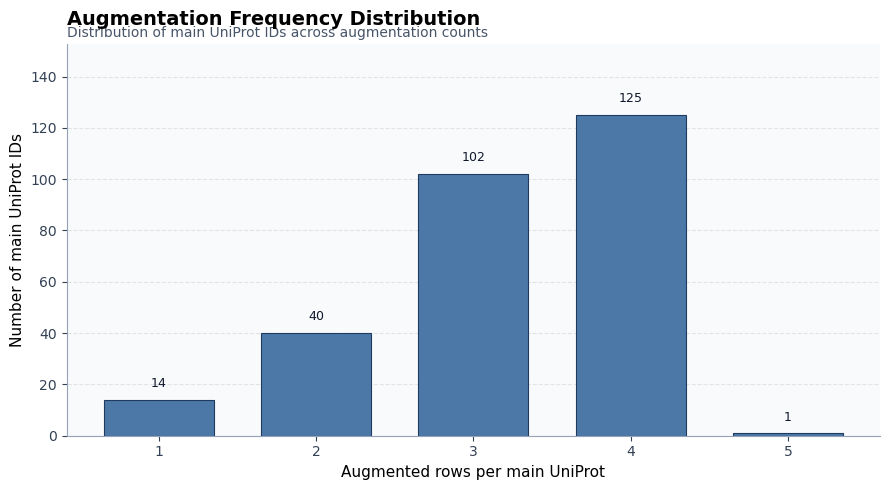

In [10]:
try:
    import matplotlib.pyplot as plt
    from matplotlib.ticker import MaxNLocator

    x = [row["augmented_rows"] for row in frequency_rows]
    y = [row["main_uniprot_count"] for row in frequency_rows]

    fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")
    ax.set_facecolor("#f8fafc")

    bars = ax.bar(x, y, width=0.7, color="#4C78A8", edgecolor="#1e3a5f", linewidth=0.8)

    ax.set_title("Augmentation Frequency Distribution", loc="left", fontsize=14, fontweight="bold", pad=14)
    ax.text(
        0,
        1.02,
        "Distribution of main UniProt IDs across augmentation counts",
        transform=ax.transAxes,
        fontsize=10,
        color="#475569",
    )

    ax.set_xlabel("Augmented rows per main UniProt", fontsize=11)
    ax.set_ylabel("Number of main UniProt IDs", fontsize=11)
    ax.set_xticks(x)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.3)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#94a3b8")
    ax.spines["bottom"].set_color("#94a3b8")
    ax.tick_params(colors="#334155")

    max_y = max(y) if y else 0
    ax.set_ylim(0, max_y * 1.22 if max_y else 1)

    for bar, row in zip(bars, frequency_rows):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(max_y * 0.03, 0.15),
            f"{row['main_uniprot_count']}",
            ha="center",
            va="bottom",
            fontsize=9,
            color="#0f172a",
        )

    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib is not installed in the current kernel; skipping plot.")